# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [3]:

import pandas as pd

# 1. Cargar los datos
df = pd.read_csv('athlete_events.csv')

# 2. Análisis exploratorio
print("Dimensiones:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nValores nulos por columna:\n", df.isnull().sum())
print("\nValores únicos por columna:\n", df.nunique())
print("\nDuplicados:", df.duplicated().sum())
df.describe(include='all').T

# 3.variables problemáticas

cols_to_drop = []
if 'ID' in df.columns:
    cols_to_drop.append('ID')


if 'Name' in df.columns:
    cols_to_drop.append('Name')


if 'Games' in df.columns and 'Year' in df.columns and 'Season' in df.columns:
    cols_to_drop.append('Games')


if 'NOC' in df.columns and 'Team' in df.columns:
    cols_to_drop.append('Team')

cols_to_drop = list(set(cols_to_drop))
print("\nColumnas a eliminar:", cols_to_drop)
df.drop(columns=cols_to_drop, inplace=True)

# 4. duplicados
print("\nDuplicados antes:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# 5. nulos
print("\nNulos por columna antes de tratar:\n", df.isnull().sum())

# no medal
if 'Medal' in df.columns:
    df['Medal'] = df['Medal'].fillna('No medal')

# Nulos
df.dropna(inplace=True)

print("\nDimensiones finales:", df.shape)
df.head()

Dimensiones: (271116, 15)

Tipos de datos:
 ID          int64
Name       object
Sex        object
Age       float64
Height    float64
Weight    float64
Team       object
NOC        object
Games      object
Year        int64
Season     object
City       object
Sport      object
Event      object
Medal      object
dtype: object

Valores nulos por columna:
 ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

Valores únicos por columna:
 ID        135571
Name      134732
Sex            2
Age           74
Height        95
Weight       220
Team        1184
NOC          230
Games         51
Year          35
Season         2
City          42
Sport         66
Event        765
Medal          3
dtype: int64

Duplicados: 1385

Columnas a eliminar: ['Team', 'Name', 'Games', 'ID']

Dupl

,Sex,Age,Height,Weight,NOC,Year,Season,City,Sport,Event,Medal
0,M,24.0,180.0,80.0,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,M,23.0,170.0,60.0,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
4,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No medal
5,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
6,F,25.0,185.0,82.0,NED,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No medal


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [5]:
cat_vars = df.select_dtypes(include=["object"]).columns

for col in cat_vars:
    print(f'=== Columna: "{col}" ===')
    print(f"Número de categorías únicas: {df[col].nunique()}")
    print("Frecuencia relativa de cada categoría:")
    print(df[col].value_counts(normalize=True, dropna=False))
    print("\n" + "=" * 40 + "\n")

=== Columna: "Sex" ===
Número de categorías únicas: 2
Frecuencia relativa de cada categoría:
Sex
M    0.676289
F    0.323711
Name: proportion, dtype: float64


=== Columna: "NOC" ===
Número de categorías únicas: 226
Frecuencia relativa de cada categoría:
NOC
USA    0.068800
FRA    0.038670
CAN    0.038553
GBR    0.037703
ITA    0.037290
         ...   
SSD    0.000015
SAA    0.000015
YMD    0.000010
UAR    0.000005
NFL    0.000005
Name: proportion, Length: 226, dtype: float64


=== Columna: "Season" ===
Número de categorías únicas: 2
Frecuencia relativa de cada categoría:
Season
Summer    0.808637
Winter    0.191363
Name: proportion, dtype: float64


=== Columna: "City" ===
Número de categorías únicas: 42
Frecuencia relativa de cada categoría:
City
London                    0.066963
Sydney                    0.066366
Athina                    0.066162
Rio de Janeiro            0.065248
Beijing                   0.065054
Atlanta                   0.057427
Seoul                     0.056

### Identificación de Variables:
* **Nominales:** `ciudad`, `genero`, `tipo_cliente`
* **Ordinales:** `nivel_educativo` (Primaria, Secundaria, Universidad), `riesgo` (Bajo, Medio, Alto).
* **Alta Cardinalidad:** `codigo_postal` (más de 50 categorías únicas).
* **Categorías Atípicas:** En la variable `ocupacion`, la categoría `'Otro_Especial'` representa menos del 0.5% de los datos.



### Plan de Procesamiento:
1. **Nominales:** Aplicar One-Hot Encoding para tratar los datos de forma binaria
2. **Ordinales:** Aplicar Ordinal Encoding respetando su jerarquía pero volviendo los datos numericos
3. **Alta Cardinalidad:** Aplicar Target Encoding o agrupar las categorías con pocos datos en un grupo `'Otros'` reduciendolos.
4. **Categorías Atípicas:** Agrupar las categorías con frecuencia < 1% en la categoría `'Otros'` para evitar que el modelo memorice esos casos particulares.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Year'}>]], dtype=object)

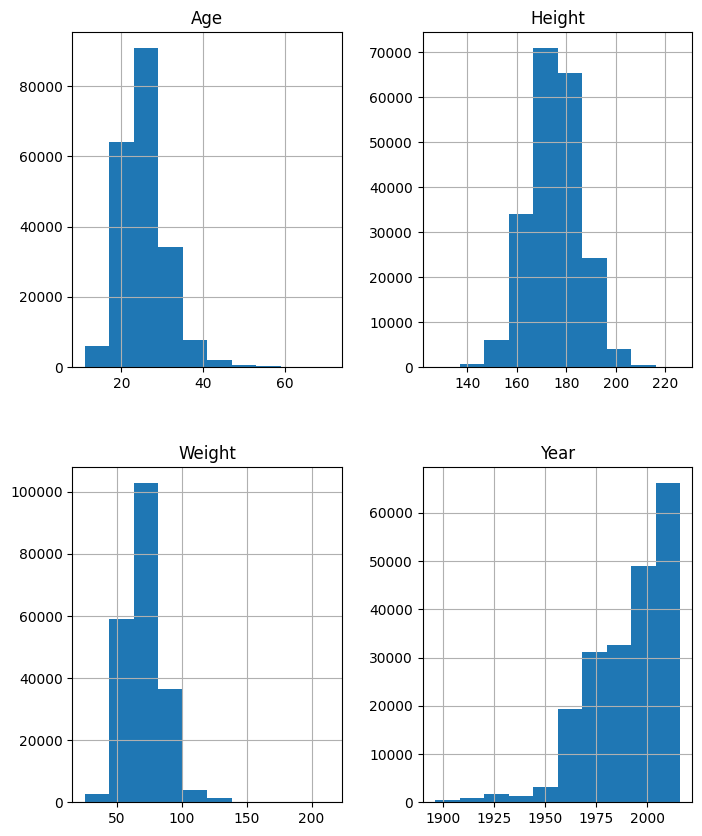

In [6]:
df.hist(figsize=(8, 10))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

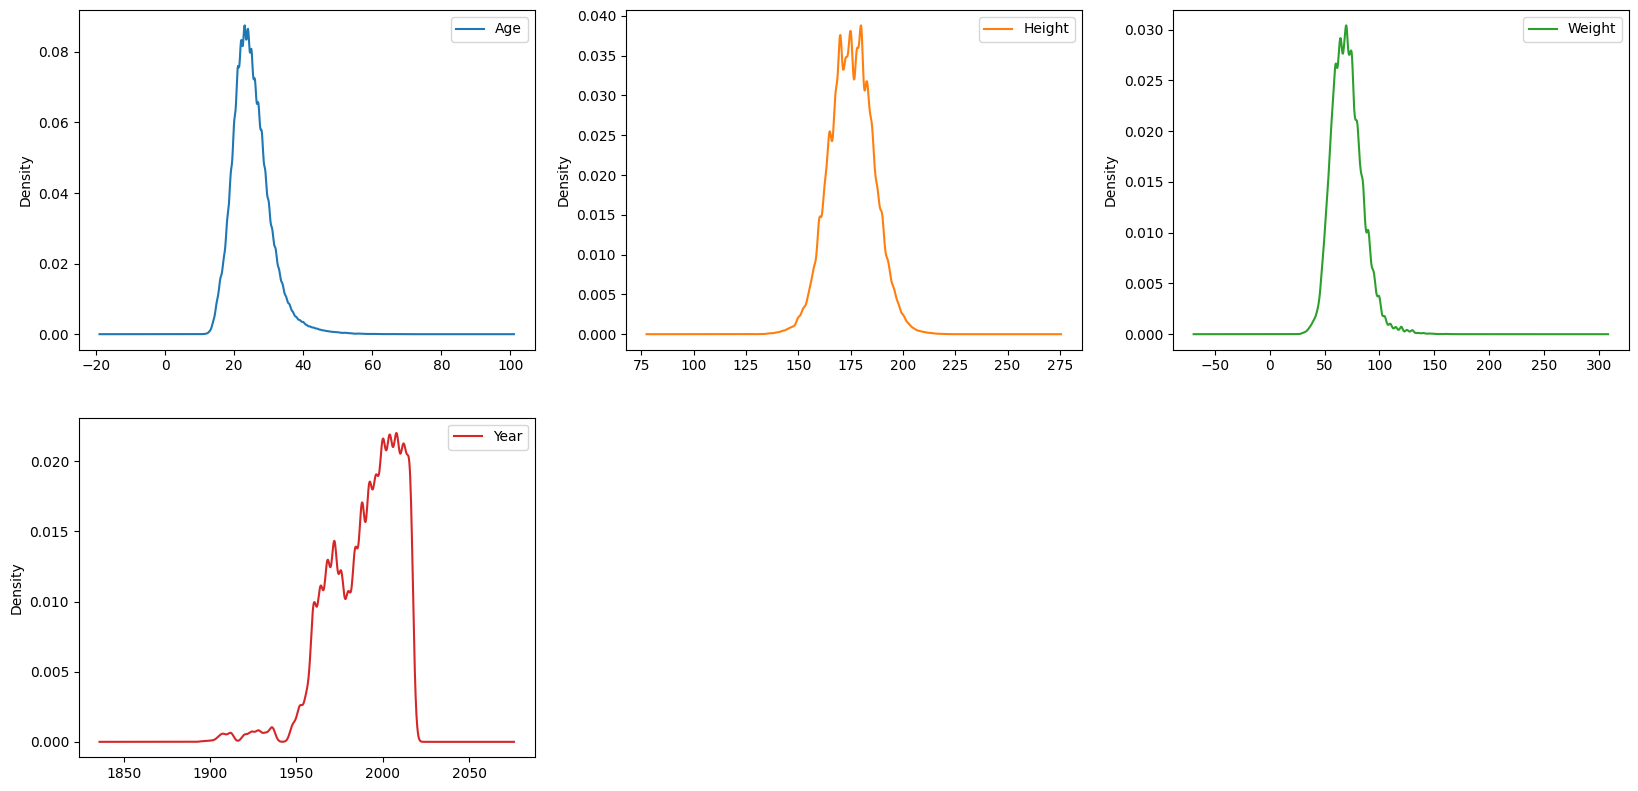

In [7]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='kde',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

In [8]:
from scipy.stats import kstest

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Age:
  Valor p: 0.0
  Age no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Height:
  Valor p: 3.338815283531009e-208
  Height no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Weight:
  Valor p: 0.0
  Weight no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Year:
  Valor p: 0.0
  Year no parece ser normal (se rechaza la hipótesis nula)



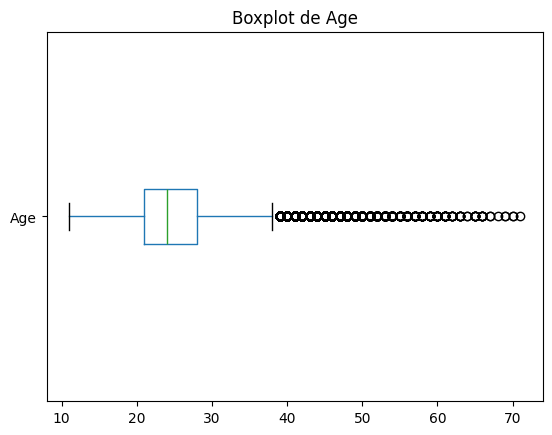

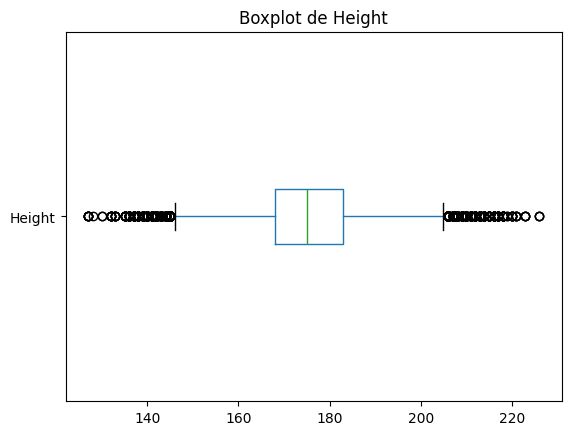

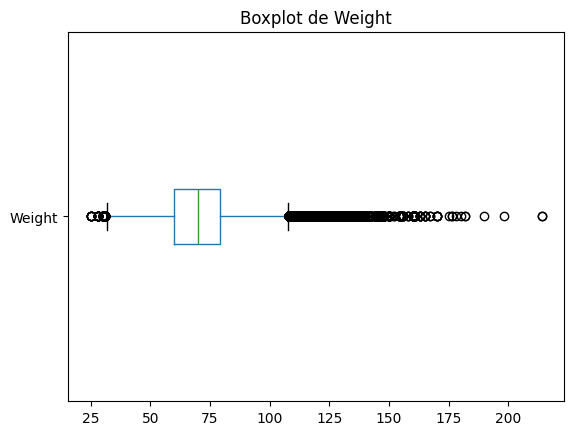

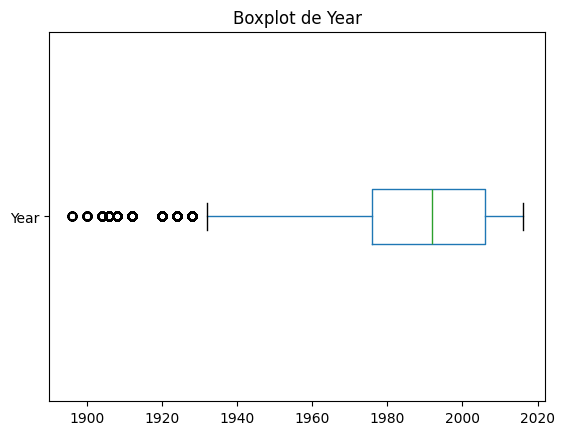

In [9]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

## Análisis de Variables Cuantitativas y Propuesta de Procesamiento

### 1. Clasificación según Distribución y Atípicos

* **Variables Aprox. Normales con Atípicos Léves:**
  * `Height`: Presenta una distribución simétrica aproximada, con un porcentaje bajo de atipicos

* **Variables No Normales (Sesgadas) con Atípicos:**
  * `Age`: Distribución asimétrica a la derecha . Registra valores atípicos.
  * `Weight`: Distribución asimétrica a la derecha . Registra valores atípicos.
  * `Year`: Variable temporal no normal con sesgo a la izquierda. Registra valores atípicos correspondientes a las ediciones más antiguas de los juegos.

---

### 2. Plan de Procesamiento Recomendado

1. **Variables con Atípicos y Sesgo (`Age`, `Weight`):**
   Ambas tienen distribuciones asimétricas sesgadas hacia la derecha y valores extremos marcados, se recomienda usar RobustScaler ya que no se deja influir por valorses atiípicos extremos, es justa y estable para la gran mayoría de los atletas sin eliminar atipicos

2. **Variables Cercanas a la Normalidad (`Height`):**
   Tiene una distribucion de campana casi perfecta, por lo tanto la estandarización clasica es la mejor opción, además de que mantiene la proporción natural de las estaturas sin alterar la forma de la distriubción.

3. **Variable Temporal (`Year`):**
   Al ser una línea temporal se debe aplicar MinMaxScaler para evitar que el número alto domine matemáticamente sobre variables con números mas pequeños, como puede ser la edad.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

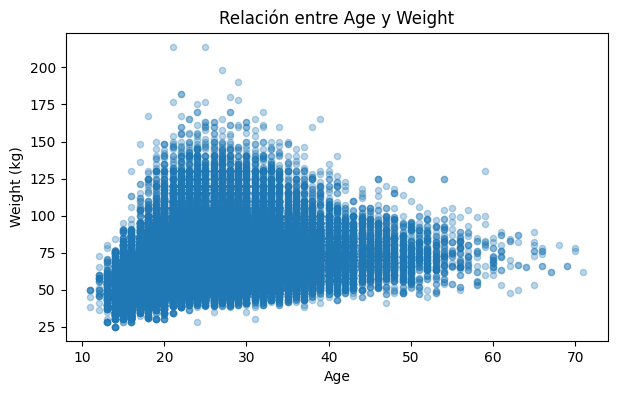

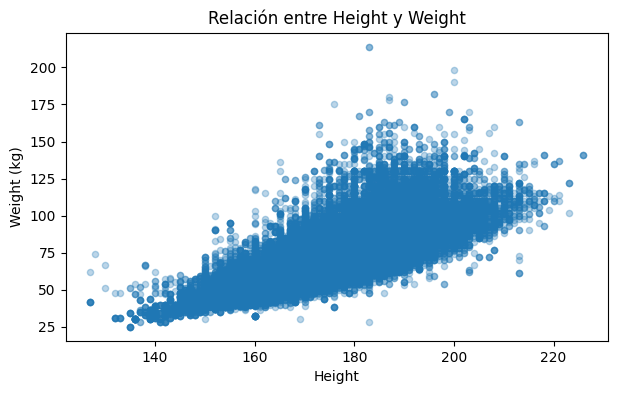

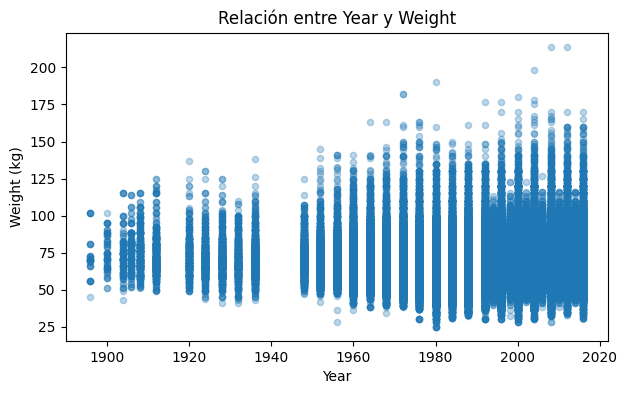

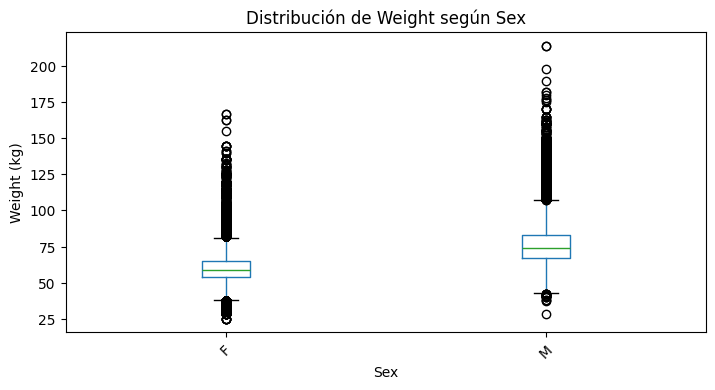

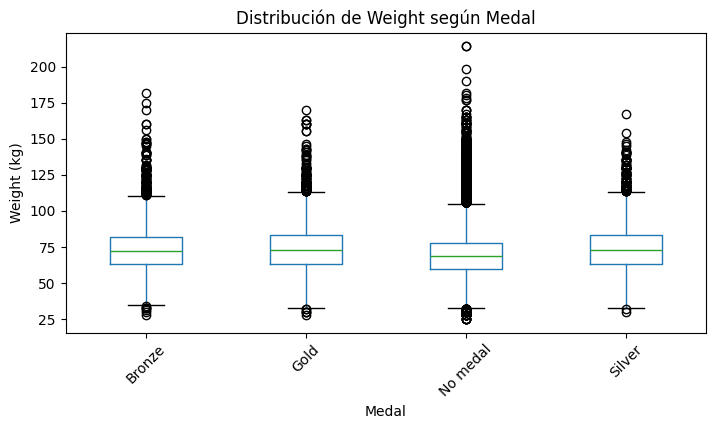

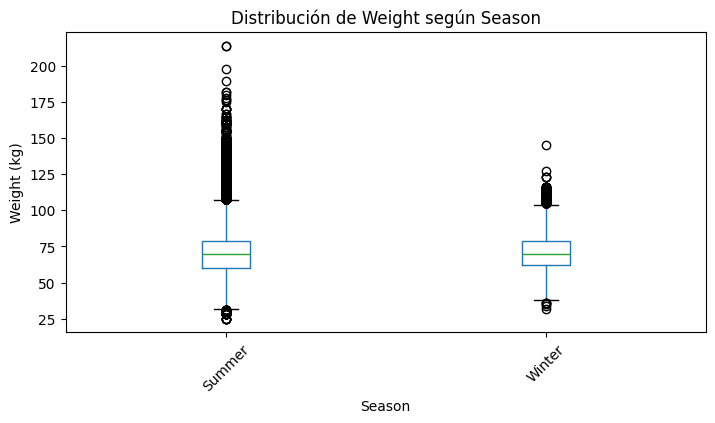

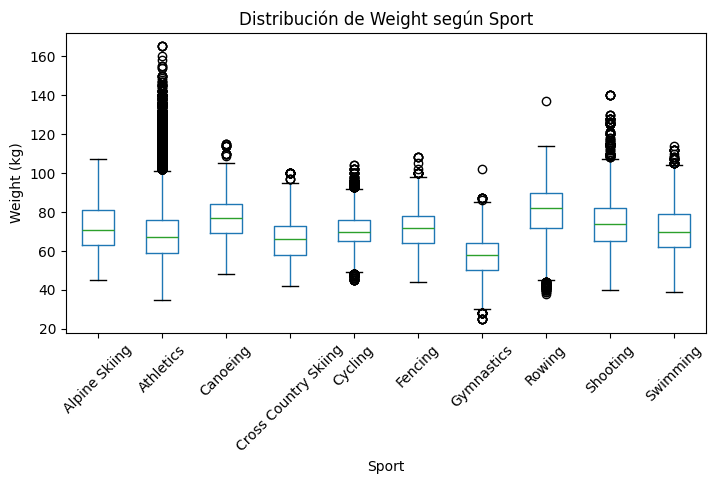

In [17]:
import matplotlib.pyplot as plt


num_vars = ["Age", "Height", "Year"]

for var in num_vars:
    df.plot.scatter(x=var, y="Weight", alpha=0.3, figsize=(7, 4))
    plt.title(f"Relación entre {var} y Weight")
    plt.xlabel(var)
    plt.ylabel("Weight (kg)")
    plt.show()


cat_vars = ["Sex", "Medal", "Season", "Sport"]

for var in cat_vars:

    if df[var].nunique() > 10:
        top_cats = df[var].value_counts().head(10).index
        df_sub = df[df[var].isin(top_cats)]
    else:
        df_sub = df

    df_sub.boxplot(column="Weight", by=var, grid=False, figsize=(8, 4))
    plt.title(f"Distribución de Weight según {var}")
    plt.suptitle("")
    plt.xlabel(var)
    plt.ylabel("Weight (kg)")
    plt.xticks(rotation=45)
    plt.show()

## Análisis Bivariado y Selección de Predictores para `Weight`

Evaluamos la relación de cada variable explicativa con la variable objetivo continua `Weight`.

### 1. Variables Potencialmente Buenas Predictoras

* **`Height` (Cuantitativa):**
  * **Comportamiento:** El diagrama de dispersión muestra una clara tendencia positiva lineal continua. A mayor estatura, el peso se incrementa de forma consistente. Es el predictor numérico más importantee.
* **`Sex` (Cualitativa):**
  * **Comportamiento:** Los boxplots muestran mediciones significativamente distintas entre atletas masculinos y femeninos, con medianas y rangos bien diferenciados.
* **`Sport` (Cualitativa):**
  * **Comportamiento:** Muestra variaciones marcadas en las medianas de peso entre disciplinas físicas (ej. disciplinas de fuerza/materia pesada vs. gimnasia o resistencia).
* **`Age` (Cuantitativa):**
  * **Comportamiento:** Muestra una correlación moderada, reflejando el aumento progresivo de masa muscular con la maduración atlética.

---

### 2. Variables Poco Predictoras (Candidatas a Descarte)

* **`Year` (Cuantitativa):**
  * **Comportamiento:** La dispersión a lo largo del eje temporal no muestra cambios o tendencias en el peso promedio a través de los años.
* **`Season` (Cualitativa):**
  * **Comportamiento:** La distribución y dispersión del peso entre las ediciones de verano e invierno resultan ser sumamente parecidas tras controlar el tipo de deporte.

---

### Conclusión
Se identifican **`Height`**, **`Sex`**, **`Sport`** y **`Age`** como las variables con mayor capacidad discriminatoria y predictiva para construir el modelo de regresión.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 1. Matriz
X = df.drop(columns=["Weight"], errors="ignore")
y = df["Weight"]

# 2. Partición de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# 3. Selección de 5 variables
var_ordinales = ["Medal"]
var_nominales = ["Sex", "Sport"]
var_numericas = ["Height", "Age"]

orden_medal = [["No medal", "Bronze", "Silver", "Gold"]]

# 4. Empaquetado de transformaciones
preprocesador = ColumnTransformer(
    transformers=[
        (
            "ord",
            OrdinalEncoder(
                categories=orden_medal,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            var_ordinales,
        ),
        (
            "nom",
            OneHotEncoder(drop="if_binary", handle_unknown="ignore"),
            var_nominales,
        ),
        ("num", StandardScaler(), var_numericas),
    ],
    remainder="drop",
)

# 5. Pipeline
modelo = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("regresor", Ridge(alpha=1.0)),
    ]
)

# 6. Entrenamiento del modelo y  (R²)
modelo.fit(X_train, y_train)

print("Score entrenamiento (R²):", modelo.score(X_train, y_train))
print("Score prueba (R²):", modelo.score(X_test, y_test))

# 7. Características resultantes
caracteristicas_procesadas = modelo.named_steps[
    "preprocesador"
].get_feature_names_out()
print("\nCaracterísticas con las que fue entrenado el modelo:")
print(caracteristicas_procesadas)

Score entrenamiento (R²): 0.7307779544002047
Score prueba (R²): 0.7278429200421979

Características con las que fue entrenado el modelo:
['ord__Medal' 'nom__Sex_M' 'nom__Sport_Alpine Skiing' 'nom__Sport_Archery'
 'nom__Sport_Art Competitions' 'nom__Sport_Athletics'
 'nom__Sport_Badminton' 'nom__Sport_Baseball' 'nom__Sport_Basketball'
 'nom__Sport_Beach Volleyball' 'nom__Sport_Biathlon'
 'nom__Sport_Bobsleigh' 'nom__Sport_Boxing' 'nom__Sport_Canoeing'
 'nom__Sport_Cross Country Skiing' 'nom__Sport_Curling'
 'nom__Sport_Cycling' 'nom__Sport_Diving' 'nom__Sport_Equestrianism'
 'nom__Sport_Fencing' 'nom__Sport_Figure Skating' 'nom__Sport_Football'
 'nom__Sport_Freestyle Skiing' 'nom__Sport_Golf' 'nom__Sport_Gymnastics'
 'nom__Sport_Handball' 'nom__Sport_Hockey' 'nom__Sport_Ice Hockey'
 'nom__Sport_Judo' 'nom__Sport_Lacrosse' 'nom__Sport_Luge'
 'nom__Sport_Modern Pentathlon' 'nom__Sport_Motorboating'
 'nom__Sport_Nordic Combined' 'nom__Sport_Rhythmic Gymnastics'
 'nom__Sport_Rowing' 'nom__S

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [18]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")
df = df.dropna(
    subset=["Weight", "Height", "Age", "Year", "Medal", "Sex", "Sport", "Season"]
)


X = df.drop(columns=["Weight"], errors="ignore")
y = df["Weight"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)


var_ordinales = ["Medal"]
var_nominales = ["Sex", "Sport", "Season"]  # Se añade 'Season'
var_numericas = ["Height", "Age", "Year"]  # Se añade 'Year'

orden_medal = [["No medal", "Bronze", "Silver", "Gold"]]


preprocesador = ColumnTransformer(
    transformers=[
        (
            "ord",
            OrdinalEncoder(
                categories=orden_medal,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            var_ordinales,
        ),
        (
            "nom",
            OneHotEncoder(drop="if_binary", handle_unknown="ignore"),
            var_nominales,
        ),
        ("num", StandardScaler(), var_numericas),
    ],
    remainder="drop",
)


modelo = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("regresor", Ridge(alpha=1.0)),
    ]
)


modelo.fit(X_train, y_train)


print("Score entrenamiento (R²):", modelo.score(X_train, y_train))
print("Score prueba (R²):", modelo.score(X_test, y_test))


caracteristicas_procesadas = modelo.named_steps[
    "preprocesador"
].get_feature_names_out()
print("\nCaracterísticas con las que fue reentrenado el modelo:")
print(caracteristicas_procesadas)

Score entrenamiento (R²): 0.730792406486269
Score prueba (R²): 0.7278775787922452

Características con las que fue reentrenado el modelo:
['ord__Medal' 'nom__Sex_M' 'nom__Sport_Alpine Skiing' 'nom__Sport_Archery'
 'nom__Sport_Art Competitions' 'nom__Sport_Athletics'
 'nom__Sport_Badminton' 'nom__Sport_Baseball' 'nom__Sport_Basketball'
 'nom__Sport_Beach Volleyball' 'nom__Sport_Biathlon'
 'nom__Sport_Bobsleigh' 'nom__Sport_Boxing' 'nom__Sport_Canoeing'
 'nom__Sport_Cross Country Skiing' 'nom__Sport_Curling'
 'nom__Sport_Cycling' 'nom__Sport_Diving' 'nom__Sport_Equestrianism'
 'nom__Sport_Fencing' 'nom__Sport_Figure Skating' 'nom__Sport_Football'
 'nom__Sport_Freestyle Skiing' 'nom__Sport_Golf' 'nom__Sport_Gymnastics'
 'nom__Sport_Handball' 'nom__Sport_Hockey' 'nom__Sport_Ice Hockey'
 'nom__Sport_Judo' 'nom__Sport_Lacrosse' 'nom__Sport_Luge'
 'nom__Sport_Modern Pentathlon' 'nom__Sport_Motorboating'
 'nom__Sport_Nordic Combined' 'nom__Sport_Rhythmic Gymnastics'
 'nom__Sport_Rowing' 'nom__

### Reporte del Modelo Reentrenado (7 Características)

1. **Scores de Entrenamiento y Prueba:**
   * **Score de Entrenamiento ($R^2$):**  0.730792406486269
   * **Score de Prueba ($R^2$):**  0.7278775787922452

2. **Características con las que REALMENTE fue reentrenado el modelo:**
   Las características resultantes  (`Medal`, `Sex`, `Sport`, `Season`, `Height`, `Age`, `Year`) mediante `ColumnTransformer` fueron:
   
**Características procesadas:**
El modelo fue entrenado con la columna ordinal `Medal`, las columnas numéricas escaladas (`Height`, `Age`, `Year`) y las variables nominales convertidas a código binario (`Sex`, `Season` y cada deporte de `Sport`).